### Step 1: Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

### Step 2: EDA

In [4]:
import urllib.request
import os
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv",
    "data/insurance.csv"
)
print("Done:", os.path.getsize('data/insurance.csv'), "bytes")

Done: 54288 bytes


In [5]:
df = pd.read_csv('data/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
print("Shape:", df.shape)

Shape: (1338, 7)


In [7]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Plot 1: Distribution of charges 

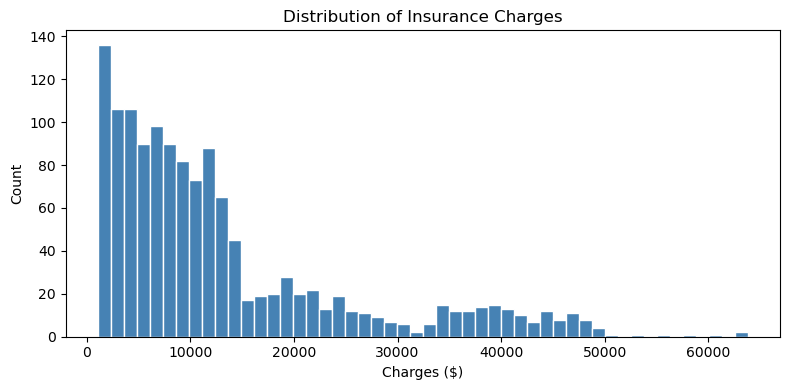

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(df['charges'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('results/charges_distribution.png', dpi=150)
plt.show()

### Plot 2: Charges by smoker

<Figure size 600x400 with 0 Axes>

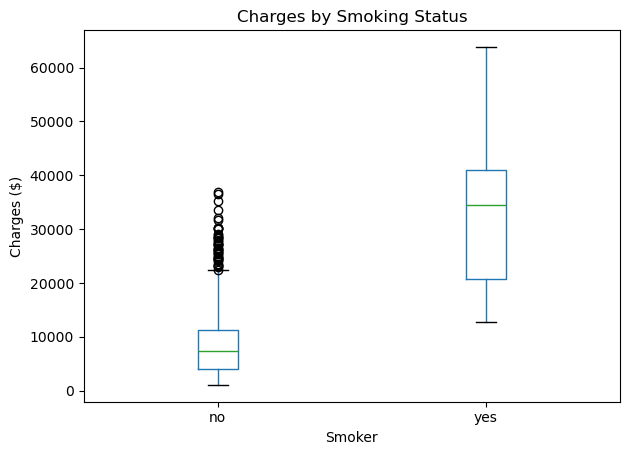

In [11]:
plt.figure(figsize=(6, 4))
df.boxplot(column='charges', by='smoker', grid=False)
plt.title('Charges by Smoking Status')
plt.suptitle('')
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.savefig('results/charges_by_smoker.png', dpi=150)
plt.show()

### Plot 3: Charges vs Age

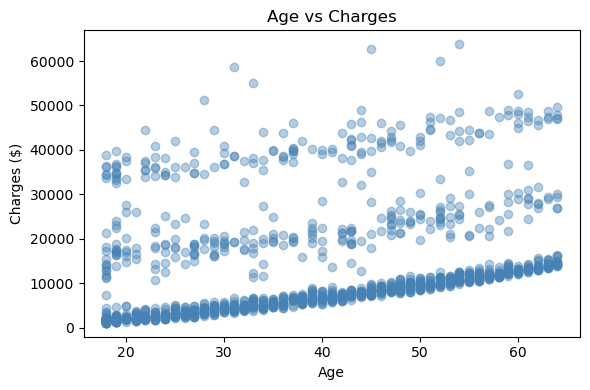

In [12]:
plt.figure(figsize=(6, 4))
plt.scatter(df['age'], df['charges'], alpha=0.4, color='steelblue')
plt.title('Age vs Charges')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.savefig('results/age_vs_charges.png', dpi=150)
plt.show()

### Plot 4: Correlation heatmap

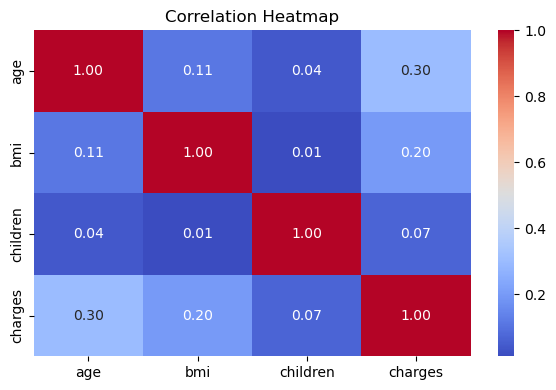

In [13]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['age','bmi','children','charges']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('results/correlation_heatmap.png', dpi=150)
plt.show()

In [14]:
df['smoker_encoded'] = (df['smoker'] == 'yes').astype(int)
print(df[['age', 'bmi', 'children', 'smoker_encoded', 'charges']].corr()['charges'])

age               0.299008
bmi               0.198341
children          0.067998
smoker_encoded    0.787251
charges           1.000000
Name: charges, dtype: float64


### Step 3: Data Preparation

In [15]:
df = pd.read_csv('data/insurance.csv')

In [16]:
# Encode smoker and sex
df['smoker'] = (df['smoker'] == 'yes').astype(int)
df['sex']    = (df['sex'] == 'male').astype(int)

In [17]:
# One-hot encode region
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [18]:
# Separate features and target
X = df.drop('charges', axis=1).values.astype(float)
y = df['charges'].values.astype(float)

In [19]:
# Train/test split
np.random.seed(42)
indices = np.arange(len(X))
np.random.shuffle(indices)
split    = int(0.8 * len(X))
X_train, X_test = X[indices[:split]], X[indices[split:]]
y_train, y_test = y[indices[:split]], y[indices[split:]]

In [20]:
# Standardise
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)
X_train_scaled = (X_train - mean) / std
X_test_scaled  = (X_test  - mean) / std

In [21]:
print("Columns:", df.drop('charges', axis=1).columns.tolist())
print("X shape:", X.shape)
print("Train:", X_train_scaled.shape, "| Test:", X_test_scaled.shape)
print("Means (~0):", X_train_scaled.mean(axis=0).round(3))
print("Stds  (~1):", X_train_scaled.std(axis=0).round(3))

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
X shape: (1338, 8)
Train: (1070, 8) | Test: (268, 8)
Means (~0): [ 0.  0.  0.  0.  0. -0.  0.  0.]
Stds  (~1): [1. 1. 1. 1. 1. 1. 1. 1.]


In [22]:
import importlib
import solution
importlib.reload(solution)
from solution import LinearRegression

# Train on age only first
X_age = X_train_scaled[:, 0].reshape(-1, 1)
X_age_test = X_test_scaled[:, 0].reshape(-1, 1)

model = LinearRegression(learning_rate=0.01, n_iterations=1000)
model.fit(X_age, y_train)

print("Train R²:", model.score(X_age, y_train).round(4))
print("Test  R²:", model.score(X_age_test, y_test).round(4))

Train R²: 0.0882
Test  R²: 0.0936


In [23]:
feature_names = ['age', 'sex', 'bmi', 'children', 'smoker', 
                 'region_nw', 'region_se', 'region_sw']

for i in range(1, len(feature_names) + 1):
    X_tr = X_train_scaled[:, :i]
    X_te = X_test_scaled[:, :i]
    
    model = LinearRegression(learning_rate=0.01, n_iterations=1000)
    model.fit(X_tr, y_train)
    
    r2 = model.score(X_te, y_test).round(4)
    print(f"Features: {feature_names[:i]} → R²: {r2}")

Features: ['age'] → R²: 0.0936
Features: ['age', 'sex'] → R²: 0.0867
Features: ['age', 'sex', 'bmi'] → R²: 0.1225
Features: ['age', 'sex', 'bmi', 'children'] → R²: 0.1276
Features: ['age', 'sex', 'bmi', 'children', 'smoker'] → R²: 0.751
Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_nw'] → R²: 0.7509
Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_nw', 'region_se'] → R²: 0.7504
Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_nw', 'region_se', 'region_sw'] → R²: 0.7513


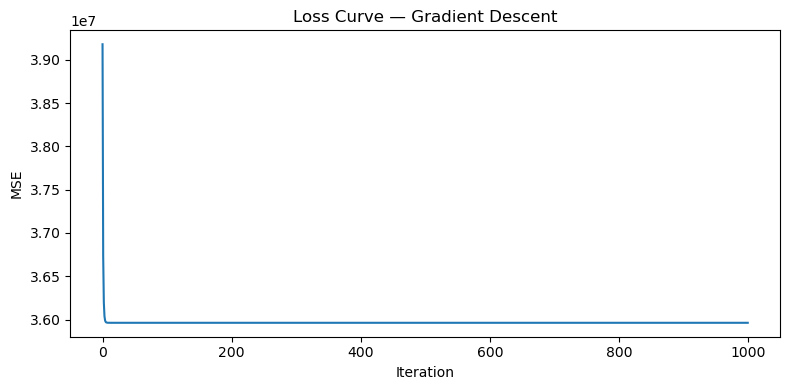

Final Train R²: 0.7505
Final Test  R²: 0.7513


In [24]:
model_full = LinearRegression(learning_rate=0.01, n_iterations=1000)
model_full.fit(X_train_scaled, y_train)

plt.figure(figsize=(8, 4))
plt.plot(model_full.loss_history)
plt.title('Loss Curve — Gradient Descent')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.tight_layout()
plt.savefig('results/loss_curve.png', dpi=150)
plt.show()

print("Final Train R²:", model_full.score(X_train_scaled, y_train).round(4))
print("Final Test  R²:", model_full.score(X_test_scaled, y_test).round(4))

In [25]:
print("Train R²:", model_full.score(X_train_scaled, y_train).round(4))
print("Test  R²:", model_full.score(X_test_scaled, y_test).round(4))

Train R²: 0.7505
Test  R²: 0.7513


In [26]:
importlib.reload(solution)
from solution import LinearRegression

# Normal Equation
model_ne = LinearRegression()
model_ne.fit_normal_equation(X_train_scaled, y_train)

# Gradient Descent
model_gd = LinearRegression(learning_rate=0.01, n_iterations=1000)
model_gd.fit(X_train_scaled, y_train)

print("Normal Equation R²:", model_ne.score(X_test_scaled, y_test).round(4))
print("Gradient Descent R²:", model_gd.score(X_test_scaled, y_test).round(4))

print("\nWeights comparison:")
print("NE weights:", model_ne.weights.round(2))
print("GD weights:", model_gd.weights.round(2))

Normal Equation R²: 0.7513
Gradient Descent R²: 0.7513

Weights comparison:
NE weights: [3642.33  -20.92 1999.7   574.44 9576.37 -150.61 -522.35 -402.22]
GD weights: [3642.33  -20.92 1999.7   574.44 9576.37 -150.61 -522.35 -402.22]


In [28]:
importlib.reload(solution)
from solution import LinearRegression, PolynomialFeatures

# Scale the polynomial column after adding it
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled, feature_idx=2)
X_test_poly  = poly.fit_transform(X_test_scaled, feature_idx=2)

# Scale the new column (column index 8 — the bmi² column)
poly_mean = X_train_poly[:, 8].mean()
poly_std  = X_train_poly[:, 8].std()

X_train_poly[:, 8] = (X_train_poly[:, 8] - poly_mean) / poly_std
X_test_poly[:, 8]  = (X_test_poly[:, 8]  - poly_mean) / poly_std

# Now train
model_poly = LinearRegression(learning_rate=0.01, n_iterations=1000)
model_poly.fit(X_train_poly, y_train)

print("Without poly R²:", model_gd.score(X_test_scaled, y_test).round(4))
print("With poly    R²:", model_poly.score(X_test_poly, y_test).round(4))

Without poly R²: 0.7513
With poly    R²: 0.7524


In [29]:
importlib.reload(solution)
from solution import LinearRegression

lambdas = [0, 0.1, 1, 10, 100]

for l2 in lambdas:
    model = LinearRegression(learning_rate=0.01, n_iterations=1000)
    model.fit(X_train_scaled, y_train, l2=l2)
    r2 = model.score(X_test_scaled, y_test).round(4)
    print(f"λ={l2:6} → R²: {r2}")

λ=     0 → R²: 0.7513
λ=   0.1 → R²: 0.7405
λ=     1 → R²: 0.5484
λ=    10 → R²: 0.1264
λ=   100 → R²: 0.0141


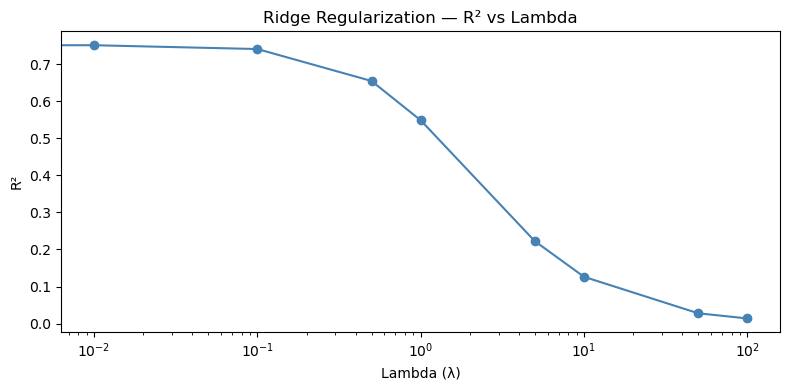

In [30]:
lambdas = [0, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100]
r2_scores = []

for l2 in lambdas:
    model = LinearRegression(learning_rate=0.01, n_iterations=1000)
    model.fit(X_train_scaled, y_train, l2=l2)
    r2_scores.append(model.score(X_test_scaled, y_test))

plt.figure(figsize=(8, 4))
plt.plot(lambdas, r2_scores, marker='o', color='steelblue')
plt.xscale('log')
plt.title('Ridge Regularization — R² vs Lambda')
plt.xlabel('Lambda (λ)')
plt.ylabel('R²')
plt.tight_layout()
plt.savefig('results/ridge_regularization.png', dpi=150)
plt.show()